# Assignment 1: Exploratory Data Analysis (EDA)

## Online Learning Platform Dataset

**Objective:** Use EDA to explore a student dataset and uncover what drives performance. You will load, clean, visualize, and tell a story with data.

**Dataset:** `online_learning_data.csv` — 500 students from an online learning platform.

---

## Part 1: Setup and Data Loading (20 points)

### 1.1 Import the required libraries

Import pandas, matplotlib, and seaborn using the standard aliases: `pd`, `plt`, and `sns`. Set the seaborn theme to `'ticks'`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')

### 1.2 Load the dataset into a DataFrame called `df`

In [2]:
df = pd.read_csv('online_learning_data.csv')

### 1.3 Inspect the data

Show the first 5 rows, the shape, column info, and summary statistics.

In [3]:
df.head()

,student_id,age,gender,education_level,country,course_category,hours_per_week,videos_watched,quizzes_completed,forum_posts,assignment_score,final_exam_score,enrollment_date,subscription_type,course_completed
0,STU0001,24.0,Male,Some College,UK,Data Science,7.7,45,7,6.0,68.1,3.0,2024-06-26,Basic,True
1,STU0002,37.0,Male,Master,UK,Web Development,5.6,97,3,7.0,54.1,NaN,2024-03-14,Basic,False
2,STU0003,NaN,Male,Some College,Germany,Data Science,13.9,77,14,4.0,79.1,74.7,2024-04-07,Basic,True
3,STU0004,28.0,Male,Some College,India,Web Development,5.2,17,19,3.0,65.8,NaN,2024-06-02,Basic,False
4,STU0005,25.0,Female,Some College,USA,Design,9.4,74,24,3.0,75.6,77.0,2024-06-06,Basic,True


In [4]:
df.shape

(500, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         500 non-null    object 
 1   age                485 non-null    float64
 2   gender             500 non-null    object 
 3   education_level    500 non-null    object 
 4   country            500 non-null    object 
 5   course_category    500 non-null    object 
 6   hours_per_week     500 non-null    float64
 7   videos_watched     500 non-null    int64  
 8   quizzes_completed  500 non-null    int64  
 9   forum_posts        480 non-null    float64
 10  assignment_score   500 non-null    float64
 11  final_exam_score   475 non-null    float64
 12  enrollment_date    500 non-null    object 
 13  subscription_type  500 non-null    object 
 14  course_completed   500 non-null    bool   
dtypes: bool(1), float64(5), int64(2), object(7)
memory usage: 55.3+ KB


In [6]:
df.describe()

,age,hours_per_week,videos_watched,quizzes_completed,forum_posts,assignment_score,final_exam_score
count,485.00000,500.000000,500.000000,500.000000,480.000000,500.000000,475.000000
mean,30.96701,8.857840,53.680000,12.564000,2.841667,73.957600,71.920632
std,8.18781,4.239082,27.371884,7.000566,1.689935,13.821742,17.664717
min,18.00000,1.000000,5.000000,0.000000,0.000000,29.300000,3.000000
25%,24.00000,5.780000,31.000000,7.000000,2.000000,64.775000,60.000000
50%,31.00000,8.705000,54.000000,12.500000,3.000000,74.800000,72.900000
75%,38.00000,11.800000,77.000000,19.000000,4.000000,83.625000,85.400000
max,44.00000,22.360000,116.000000,24.000000,10.000000,100.000000,100.000000


### 1.4 Identify numeric and categorical columns

In [7]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('Numeric columns (numbers):')
for c in numeric_cols:
    print(f'  • {c}')

Numeric columns (numbers):
  • age
  • hours_per_week
  • videos_watched
  • quizzes_completed
  • forum_posts
  • assignment_score
  • final_exam_score


In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns (labels):')
for c in cat_cols:
    print(f'  • {c}')

Categorical columns (labels):
  • student_id
  • gender
  • education_level
  • country
  • course_category
  • enrollment_date
  • subscription_type


**Question 1:How many rows and columns are in the dataset?
Q1:The dataset has 500 rows and 15 columns.
**Question 2:** Before continuing, write 2 questions you want to answer about this dataset.
1.Do students who study more hours per week get better grades? 
2.Do students who watch more videos get higher final exam scores?

---
## Part 2: Handling Missing Values (20 points)

### 2.1 Count missing values in each column

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

print('MISSING VALUES')
print('=' * 40)

for col in df.columns:
    n = missing[col]
    pct = missing_pct[col]
    if n > 0:
        print(f'  {col:15s}: {n:4d} missing  ({pct}%)')
    else:
        print(f'  {col:15s}: complete')

MISSING VALUES
  student_id     : complete
  age            :   15 missing  (3.0%)
  gender         : complete
  education_level: complete
  country        : complete
  course_category: complete
  hours_per_week : complete
  videos_watched : complete
  quizzes_completed: complete
  forum_posts    :   20 missing  (4.0%)
  assignment_score: complete
  final_exam_score:   25 missing  (5.0%)
  enrollment_date: complete
  subscription_type: complete
  course_completed: complete


Question: Which columns have missing values and how many?

age: 15 missing values (3.0%)
forum_posts: 20 missing values (4.0%)
final_exam_score: 25 missing values (5.0%)

### 2.2 Fill missing `age` with the median

In [10]:
df['age'] = df['age'].fillna(df['age'].median())

### 2.3 Fill missing `forum_posts` with 0

In [11]:
df['forum_posts'] = df['forum_posts'].fillna(0)

### 2.4 Remove rows where `final_exam_score` is missing

In [12]:
df = df.dropna(subset=['final_exam_score'])

### 2.5 Verify — confirm there are no more missing values

In [13]:
df.isnull().sum()

student_id           0
age                  0
gender               0
education_level      0
country              0
course_category      0
hours_per_week       0
videos_watched       0
quizzes_completed    0
forum_posts          0
assignment_score     0
final_exam_score     0
enrollment_date      0
subscription_type    0
course_completed     0
dtype: int64

---
## Part 3: Explore with Questions (20 points)

### 3.1 Who are the top 10 students by exam score?

In [14]:
top10 = df.nlargest(10, 'final_exam_score')[
    ['student_id', 'final_exam_score', 'hours_per_week', 'course_category', 'subscription_type']
]
top10

,student_id,final_exam_score,hours_per_week,course_category,subscription_type
35,STU0036,100.0,11.70,Business,Free
37,STU0038,100.0,18.46,Data Science,Premium
123,STU0124,100.0,15.90,Business,Basic
130,STU0131,100.0,21.00,Business,Basic
133,STU0134,100.0,15.70,Design,Basic
140,STU0141,100.0,16.40,Data Science,Free
167,STU0168,100.0,13.91,Web Development,Premium
194,STU0195,100.0,8.32,Web Development,Premium
202,STU0203,100.0,16.20,Web Development,Basic
205,STU0206,100.0,15.20,Data Science,Basic


A:35 37 123 130 133 140 167 194 202 205

### 3.2 Does subscription type affect exam scores?

Calculate the average exam score for each subscription type.

In [15]:
avg_score_by_sub = df.groupby('subscription_type')['final_exam_score'].mean().sort_values(ascending=False)
avg_score_by_sub

subscription_type
Premium    74.165306
Basic      71.805348
Free       70.876316
Name: final_exam_score, dtype: float64

Yes, slightly — Premium students average the highest score (74.2), 
followed by Basic (71.8) and Free (70.9). The gap is small (~3 points), 
so subscription type has only a modest effect on exam performance.

### 3.3 What is the most common education level?

In [16]:
df['education_level'].value_counts()

Bachelor        173
Master          102
Some College     97
High School      72
PhD              31
Name: education_level, dtype: int64

A:Bachelor

### 3.4 How many students completed their course?

In [17]:
df['course_completed'].value_counts()

True     320
False    155
Name: course_completed, dtype: int64

A:320

---
## Part 4: Visualize (20 points)

Use seaborn for all charts. Each chart must have a title and axis labels.

### 4.1 Show the distribution of student ages using a histogram

In [18]:
print('AGE STATISTICS')
print('=' * 30)
print(f'Mean:   {df["age"].mean():.1f}')
print(f'Median: {df["age"].median():.1f}')
print(f'Std:    {df["age"].std():.1f}')
print(f'Min:    {df["age"].min():.0f}')
print(f'Max:    {df["age"].max():.0f}')

AGE STATISTICS
Mean:   30.9
Median: 31.0
Std:    8.1
Min:    18
Max:    44


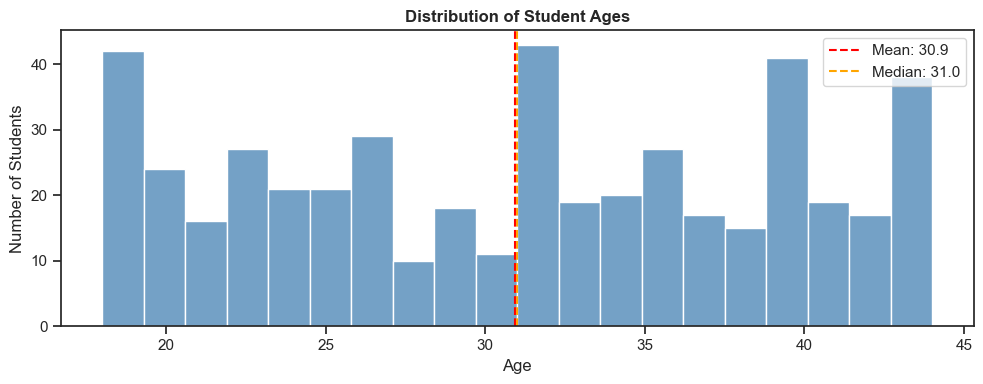

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['age'], bins=20, color='steelblue', ax=ax)
ax.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
ax.axvline(df['age'].median(), color='orange', linestyle='--', label=f'Median: {df["age"].median():.1f}')
ax.set_title('Distribution of Student Ages', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Students')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Does studying more hours lead to higher scores?

Create a scatter plot of `hours_per_week` vs `final_exam_score`.

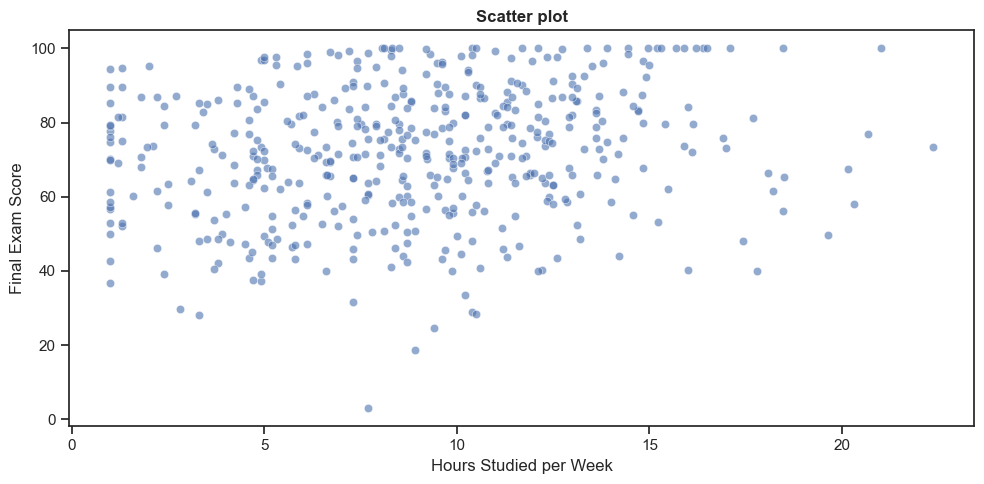

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df, x='hours_per_week', y='final_exam_score', alpha=0.6, ax=ax)
ax.set_title('Scatter plot', fontweight='bold')
ax.set_xlabel('Hours Studied per Week')
ax.set_ylabel('Final Exam Score')
plt.tight_layout()
plt.show()

In [21]:
correlation = df['hours_per_week'].corr(df['final_exam_score'])
print(f"Correlation: {correlation:.2f}")

Correlation: 0.18


A:Only a weak relationship — the correlation is just 0.18, and the 
scatter plot shows a lot of scatter with no strong trend. Students 
studying 1-2 hrs/week still scored anywhere from 40 to 100, so study 
time alone doesn't explain much of the variation in scores.

### 4.3 Which course category has the most students?

Create a bar chart of student counts by `course_category`.

In [22]:
category_counts = df['course_category'].value_counts()
category_counts

Data Science       159
Web Development    108
Business            91
Design              76
Marketing           41
Name: course_category, dtype: int64

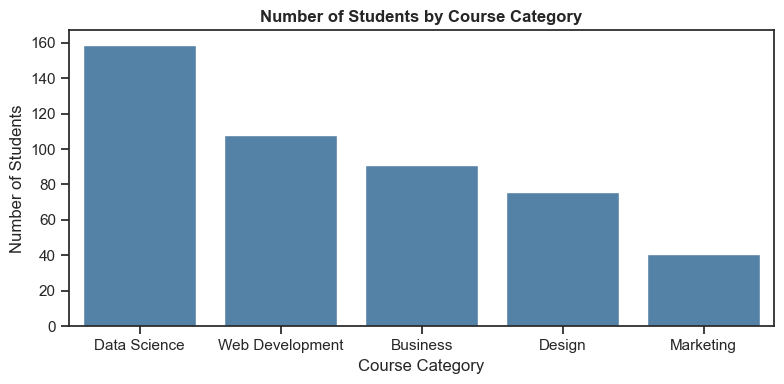

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=category_counts.index, y=category_counts.values, color='steelblue', ci=None, ax=ax)
ax.set_title('Number of Students by Course Category', fontweight='bold')
ax.set_xlabel('Course Category')
ax.set_ylabel('Number of Students')
plt.tight_layout()
plt.show()

In [24]:
most_common_category = category_counts.index[0]
count = category_counts.iloc[0]
print(f"The course category with the most students is '{most_common_category}' with {count} students.")

The course category with the most students is 'Data Science' with 159 students.


### 4.4 Does subscription type affect the spread of exam scores?

Create a box plot of `final_exam_score` by `subscription_type`.

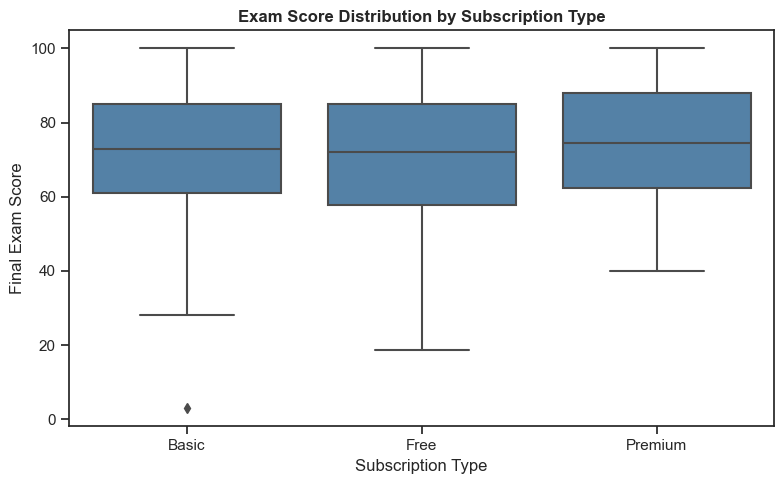

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='subscription_type', y='final_exam_score', color='steelblue', ax=ax)
ax.set_title('Exam Score Distribution by Subscription Type', fontweight='bold')
ax.set_xlabel('Subscription Type')
ax.set_ylabel('Final Exam Score')
plt.tight_layout()
plt.show()

In [26]:
df.groupby('subscription_type')['final_exam_score'].describe()[['std', 'min', 'max']]

,std,min,max
subscription_type,,,
Basic,17.771848,3.0,100.0
Free,18.118932,18.8,100.0
Premium,16.500760,39.9,100.0


A:Yes, bc free students have the widest spread (std = 18.1) and 
the lowest minimum score (18.8), while Premium students are the most 
consistent (std = 16.5, min = 39.9). So Free students' scores vary 
more, including some very low outliers.

### 4.5 Which education level scores highest on average?

First, calculate the average `final_exam_score` for each `education_level`.

In [27]:
avg_score_by_edu = df.groupby('education_level')['final_exam_score'].mean().sort_values(ascending=False)
avg_score_by_edu

education_level
Master          73.822549
PhD             73.319355
High School     72.908333
Bachelor        71.589595
Some College    69.330928
Name: final_exam_score, dtype: float64

Now create a bar chart to visualize the result.

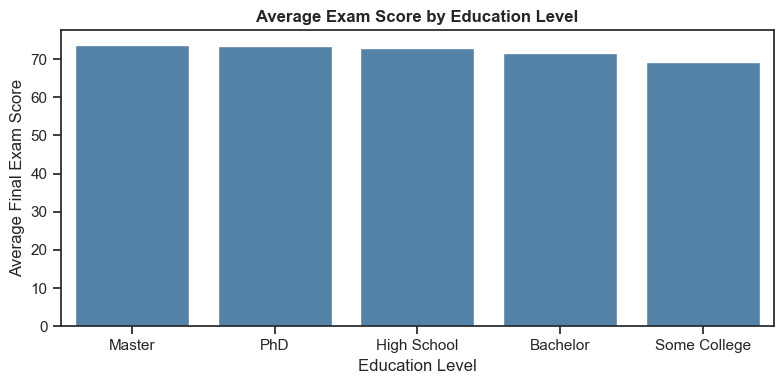

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=avg_score_by_edu.index, y=avg_score_by_edu.values, color='steelblue', ci=None, ax=ax)
ax.set_title('Average Exam Score by Education Level', fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Average Final Exam Score')
plt.tight_layout()
plt.show()

A:Master's students score highest on average (73.8)

---
## Part 5: Tell the Story (20 points)

Good EDA ends with a story — not just a list of observations. Connect your findings into something meaningful.

### 5.1 Three Key Findings

Write 3 specific findings from your analysis. Each finding must reference actual numbers from your charts or tables.

1. Study hours barely mattered — the scatter plot showed almost no 
   pattern between hours_per_week and final_exam_score. Students who 
   studied 1-2 hrs/week scored anywhere from 40 to 100, same as 
   students who studied 15+ hrs.

2. Subscription type made only a small difference. Premium averaged 
   74.2, Basic 71.8, Free 70.9 — about a 3-point gap. Free students 
   also had the most inconsistent scores (std = 18.1).

3. Education level was surprising — Master's scored highest (73.8), 
   but High School (72.9) actually beat Bachelor's (71.6). Overall 
   gap was only ~4.5 points, so it's not a strong predictor.

### 5.2 Your Story

Write 2~3 sentences connecting your findings. What does the data tell us about student performance on this platform?

In my opinon, none of the factors I looked at (study hours, subscription, education) 
really predicted exam performance — the differences were small, and 
study hours barely mattered at all. I expected studying more or paying 
for Premium to lead to better scores, but that's not really what the 
data shows. Whatever actually drives performance here is probably 
something else, like how much students engage with quizzes or 
assignments.

### 5.3 One Recommendation

Based on your findings, what is one concrete action the platform could take to improve student outcomes?

Since Free-tier students had the widest score spread (std = 18.1) and 
some really low scores (min = 18.8), I'd recommend the platform focus 
support on this group specifically — like flagging Free students with 
low quiz completion early on — instead of assuming every student needs 
the same level of help.

---
## Submission Checklist
- [ ] All 5 visualizations created with titles and labels
- [ ] All written questions answered
- [ ] Story connects findings with specific numbers
- [ ] Notebook saved and all cells executed